# FoodBridge SG — Beneficiary Dashboard Engine
### IS215 Digital Business – Technologies and Transformation

This notebook powers the **beneficiary-facing dashboard** of FoodBridge SG.  
It reads raw historical sales data, computes actual observed daily surplus at each store using a rolling-average proxy, then runs the AI matching engine to recommend the best stores for each NPO to collect from.

**Inputs:** Raw CSVs (`training.csv`, `items.csv`, `stores.csv`, `transactions.csv`, `oil.csv`, `holidays_events.csv`)  
**Outputs:** `dashboard_payload.json` — a single file containing all dashboard data  

> **Run order:** This notebook is self-contained. `analytics.ipynb` does not need to be run first — the beneficiary dashboard computes actual surplus directly from raw data rather than relying on the RF forecast.

---
## Configuration & Imports

All tunable parameters are defined here in one place — making it easy to adjust behaviour without hunting through the code:

- `MAX_DISTANCE_KM` — radius within which stores are considered "nearby" for a given NPO
- `TOP_N_MATCHES` — maximum number of AI match cards shown on the dashboard
- `FOOD_PRICE_PER_KG` — estimated SGD value per kg used to compute the "money saved" metric

The dashboard reads raw sales data directly and computes actual observed surplus — no pre-generated forecast file is needed.  
The **Haversine formula** (imported via `math`) calculates real-world distance between two GPS coordinates — used in the matching engine.

In [21]:
import pandas as pd
import numpy as np
import json
from math import radians, sin, cos, sqrt, atan2
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ── Tunable parameters ────────────────────────────────────────────────────
MAX_DISTANCE_KM   = 10.0   # Stores beyond this are excluded from matching
TOP_N_MATCHES     = 5      # Max match cards shown per beneficiary
FOOD_PRICE_PER_KG = 4.50   # SGD per kg — used for money saved calculation
TODAY             = datetime.today().strftime('%d %b %Y')

print("=" * 60)
print("  FoodBridge SG — Beneficiary Dashboard Engine")
print(f"  Running for: {TODAY}")
print("=" * 60)
import matplotlib.pyplot as plt
import numpy as np


  FoodBridge SG — Beneficiary Dashboard Engine
  Running for: 29 Mar 2026


---
## Stage 1: Load All Raw Data

We load the same 6 source CSVs used by the analytics pipeline (no `testing.csv` needed here — we are generating outputs, not predicting future rows).

All `date` columns are converted to `datetime` immediately.  
This is a defensive practice — downstream stages compare dates using `>=` and `-`, which will raise a `TypeError` if dates are still strings.

In [22]:
print("\n[1/7] Loading raw data...")

train        = pd.read_csv('training.csv')
items        = pd.read_csv('items.csv')
stores       = pd.read_csv('stores.csv')
transactions = pd.read_csv('transactions.csv')
oil          = pd.read_csv('oil.csv')
holidays     = pd.read_csv('holidays_events.csv')

for df, col in [(train,'date'),(transactions,'date'),(oil,'date'),(holidays,'date')]:
    df[col] = pd.to_datetime(df[col])

print(f"  train: {len(train):,} rows | items: {len(items)} | stores: {len(stores)}")
print("  ✓ Raw data loaded")


[1/7] Loading raw data...
  train: 750,000 rows | items: 4100 | stores: 54
  ✓ Raw data loaded


---
## Stage 2: Compute Actual Daily Surplus

The beneficiary dashboard computes **actual observed surplus** directly from raw historical data.

**Why use actual data here instead of RF predictions?**  
Beneficiaries need to act on real, available surplus — not a forecast. The rolling-average proxy gives us the best available estimate of what is *actually left unsold* at each store on the latest recorded day, making the matching recommendations grounded in observed reality rather than a model's extrapolation.

**The computation:**
1. Filter to perishable items only (same as analytics)
2. Compute a 7-day shifted rolling average of sales per store-item pair — this represents the "expected" sales volume
3. `estimated_waste = (avg_sales_7d − unit_sales).clip(lower=0)` — the gap between expectation and reality, floored at zero
4. Take the **most recent date** in the dataset and aggregate `estimated_waste` to store level

The resulting `surplus` DataFrame has the same column names (`store_nbr`, `total_predicted_waste`, `top_waste_category`, `city`, `state`, `type`) that the AI Matching Engine in Stage 5 expects — so all downstream cells work without modification.

In [23]:
print("\n[2/7] Computing actual daily surplus from historical data...")

# Filter to perishable items only
perishables = items[items['perishable'] == 1][['item_nbr', 'family']]
df = train.merge(perishables, on='item_nbr', how='inner')
df = df.sort_values(['store_nbr', 'item_nbr', 'date']).reset_index(drop=True)

# 7-day shifted rolling average — "expected" sales, using prior days only (no leakage)
df['avg_sales_7d'] = (
    df.groupby(['store_nbr', 'item_nbr'])['unit_sales']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

# Actual surplus proxy: gap between expected and actual, never negative
df['estimated_waste'] = (df['avg_sales_7d'] - df['unit_sales']).clip(lower=0)
df = df.dropna(subset=['avg_sales_7d'])

# Use the most recent date in the dataset
latest_date = df['date'].max()
print(f"  Using actual data for: {latest_date.date()}")

latest_df = df[df['date'] == latest_date].copy()

# Aggregate to store level
actual_surplus = (
    latest_df.groupby('store_nbr')
    .agg(
        total_surplus=('estimated_waste', 'sum'),
        top_waste_category=('family', lambda x: latest_df.loc[x.index]
                            .groupby('family')['estimated_waste']
                            .sum().idxmax())
    )
    .reset_index()
)

actual_surplus = actual_surplus.merge(
    stores[['store_nbr', 'city', 'state', 'type']], on='store_nbr', how='left'
)
actual_surplus['forecast_date'] = latest_date.date()

# Rename to match the column name the matching engine expects
surplus = actual_surplus.rename(columns={'total_surplus': 'total_predicted_waste'})

print(f"  ✓ Actual surplus computed — {len(surplus)} stores with surplus data")
surplus.head()


[2/7] Computing actual daily surplus from historical data...
  Using actual data for: 2013-12-01
  ✓ Actual surplus computed — 46 stores with surplus data


,store_nbr,total_predicted_waste,top_waste_category,city,state,type,forecast_date
0,1,372.817476,DAIRY,Quito,Pichincha,D,2013-12-01
1,2,318.662024,MEATS,Quito,Pichincha,D,2013-12-01
2,3,506.112571,POULTRY,Quito,Pichincha,D,2013-12-01
3,4,355.921595,BREAD/BAKERY,Quito,Pichincha,D,2013-12-01
4,5,332.222000,BREAD/BAKERY,Santo Domingo,Santo Domingo de los Tsachilas,D,2013-12-01


---
## Stage 3: Beneficiary Profile & Pickup History

In production, this data comes from the app's database — each NPO's registration record and their complete history of confirmed pickups.

For this prototype, we simulate it directly in code.

**Key design decisions:**
- `pickup_date` is converted to `datetime` **immediately** after the DataFrame is created — before any subset (`completed`/`pending`) is formed. This is critical: if conversion happens later, date comparisons in Stage 6 raise a `TypeError` because strings and `datetime` objects cannot be compared with `>=`.
- `history_counts` aggregates past completed collections per store — this feeds into the matching score as the "relationship history" signal.

In [42]:
print("\n[3/7] Loading beneficiary profile and history...")

BENEFICIARY = {
    'id':          'BEN_001',
    'name':        'Food From The Heart',
    'latitude':    1.3521,
    'longitude':   103.8198,
    'preferences': ['BREAD/BAKERY', 'DELI', 'DAIRY EGGS', 'PRODUCE'],
    'joined_date': '2024-01-15'
}

pickup_history = pd.DataFrame([
    # This week (0-6 days ago) — 3 records
    {'item_name': 'Vegetables', 'quantity_kg': 30, 'store_name': 'Quito Store #3',
     'store_nbr': 3, 'distance_km': 2.3,
     'pickup_date': (datetime.today() - timedelta(days=1)).strftime('%Y-%m-%d'), 'status': 'pending'},
    {'item_name': 'Bread',      'quantity_kg': 20, 'store_name': 'Quito Store #7',
     'store_nbr': 7, 'distance_km': 2.7,
     'pickup_date': (datetime.today() - timedelta(days=2)).strftime('%Y-%m-%d'), 'status': 'pending'},
    {'item_name': 'Rice',       'quantity_kg': 45, 'store_name': 'Quito Store #3',
     'store_nbr': 3, 'distance_km': 2.3,
     'pickup_date': (datetime.today() - timedelta(days=3)).strftime('%Y-%m-%d'), 'status': 'complete'},
    # Last week (7-13 days ago) — 3 records
    {'item_name': 'Condiments', 'quantity_kg': 20, 'store_name': 'Quito Store #3',
     'store_nbr': 3, 'distance_km': 2.3,
     'pickup_date': (datetime.today() - timedelta(days=8)).strftime('%Y-%m-%d'), 'status': 'complete'},
    {'item_name': 'Dairy',      'quantity_kg': 25, 'store_name': 'Cayambe Store #11',
     'store_nbr': 11, 'distance_km': 3.4,
     'pickup_date': (datetime.today() - timedelta(days=9)).strftime('%Y-%m-%d'), 'status': 'complete'},
    {'item_name': 'Fruits',     'quantity_kg': 15, 'store_name': 'Ibarra Store #15',
     'store_nbr': 15, 'distance_km': 3.0,
     'pickup_date': (datetime.today() - timedelta(days=11)).strftime('%Y-%m-%d'), 'status': 'complete'},
    # 2 weeks ago (14-20 days ago) — 3 records
    {'item_name': 'Bread',      'quantity_kg': 35, 'store_name': 'Quito Store #3',
     'store_nbr': 3, 'distance_km': 2.3,
     'pickup_date': (datetime.today() - timedelta(days=15)).strftime('%Y-%m-%d'), 'status': 'complete'},
    {'item_name': 'Eggs',       'quantity_kg': 10, 'store_name': 'Quito Store #7',
     'store_nbr': 7, 'distance_km': 2.7,
     'pickup_date': (datetime.today() - timedelta(days=17)).strftime('%Y-%m-%d'), 'status': 'complete'},
    {'item_name': 'Meat',       'quantity_kg': 40, 'store_name': 'Quito Store #20',
     'store_nbr': 20, 'distance_km': 4.1,
     'pickup_date': (datetime.today() - timedelta(days=19)).strftime('%Y-%m-%d'), 'status': 'complete'},
    # 3 weeks ago (21-27 days ago) — 2 records
    {'item_name': 'Rice',       'quantity_kg': 50, 'store_name': 'Quito Store #3',
     'store_nbr': 3, 'distance_km': 2.3,
     'pickup_date': (datetime.today() - timedelta(days=22)).strftime('%Y-%m-%d'), 'status': 'complete'},
    {'item_name': 'Vegetables', 'quantity_kg': 25, 'store_name': 'Cayambe Store #11',
     'store_nbr': 11, 'distance_km': 3.4,
     'pickup_date': (datetime.today() - timedelta(days=25)).strftime('%Y-%m-%d'), 'status': 'complete'},
    # 4 weeks ago (28-34 days ago) — 2 records
    {'item_name': 'Condiments', 'quantity_kg': 15, 'store_name': 'Ibarra Store #15',
     'store_nbr': 15, 'distance_km': 3.0,
     'pickup_date': (datetime.today() - timedelta(days=30)).strftime('%Y-%m-%d'), 'status': 'complete'},
    {'item_name': 'Bread',      'quantity_kg': 30, 'store_name': 'Quito Store #7',
     'store_nbr': 7, 'distance_km': 2.7,
     'pickup_date': (datetime.today() - timedelta(days=32)).strftime('%Y-%m-%d'), 'status': 'complete'},
    # 5-6 weeks ago — 3 records
    {'item_name': 'Dairy',      'quantity_kg': 20, 'store_name': 'Quito Store #3',
     'store_nbr': 3, 'distance_km': 2.3,
     'pickup_date': (datetime.today() - timedelta(days=37)).strftime('%Y-%m-%d'), 'status': 'complete'},
    {'item_name': 'Fruits',     'quantity_kg': 12, 'store_name': 'Quito Store #20',
     'store_nbr': 20, 'distance_km': 4.1,
     'pickup_date': (datetime.today() - timedelta(days=40)).strftime('%Y-%m-%d'), 'status': 'complete'},
    {'item_name': 'Rice',       'quantity_kg': 35, 'store_name': 'Quito Store #3',
     'store_nbr': 3, 'distance_km': 2.3,
     'pickup_date': (datetime.today() - timedelta(days=42)).strftime('%Y-%m-%d'), 'status': 'complete'},
    # 7-8 weeks ago — 2 records
    {'item_name': 'Vegetables', 'quantity_kg': 18, 'store_name': 'Cayambe Store #11',
     'store_nbr': 11, 'distance_km': 3.4,
     'pickup_date': (datetime.today() - timedelta(days=50)).strftime('%Y-%m-%d'), 'status': 'complete'},
    {'item_name': 'Meat',       'quantity_kg': 30, 'store_name': 'Quito Store #7',
     'store_nbr': 7, 'distance_km': 2.7,
     'pickup_date': (datetime.today() - timedelta(days=55)).strftime('%Y-%m-%d'), 'status': 'complete'},
])

# Convert to datetime BEFORE creating any subsets — prevents TypeError in Stage 6
pickup_history['pickup_date'] = pd.to_datetime(pickup_history['pickup_date'])

history_counts = (
    pickup_history[pickup_history['status'] == 'complete']
    .groupby('store_nbr')['item_name']
    .count()
    .reset_index()
    .rename(columns={'item_name': 'collections'})
)

print(f"  ✓ Profile loaded — {len(pickup_history)} past pickups")
pickup_history


[3/7] Loading beneficiary profile and history...
  ✓ Profile loaded — 18 past pickups


,item_name,quantity_kg,store_name,store_nbr,distance_km,pickup_date,status
0,Vegetables,30,Quito Store #3,3,2.3,2026-03-28,pending
1,Bread,20,Quito Store #7,7,2.7,2026-03-27,pending
2,Rice,45,Quito Store #3,3,2.3,2026-03-26,complete
3,Condiments,20,Quito Store #3,3,2.3,2026-03-21,complete
4,Dairy,25,Cayambe Store #11,11,3.4,2026-03-20,complete
5,Fruits,15,Ibarra Store #15,15,3.0,2026-03-18,complete
6,Bread,35,Quito Store #3,3,2.3,2026-03-14,complete
7,Eggs,10,Quito Store #7,7,2.7,2026-03-12,complete
8,Meat,40,Quito Store #20,20,4.1,2026-03-10,complete
9,Rice,50,Quito Store #3,3,2.3,2026-03-07,complete


---
## Stage 4: Store Coordinates

The matching engine needs GPS coordinates to calculate distance between each NPO and each store.  
The `stores.csv` only has city names, so we map them to approximate latitude/longitude values.

**Haversine formula:**  
We use the Haversine formula rather than straight-line (Euclidean) distance because it accounts for the curvature of the Earth, giving accurate real-world distances in kilometres between two GPS points.

> In a production system, replace this dictionary with a call to the **Google Maps Geocoding API** to get precise coordinates for each store address.

In [43]:
# Individual store coordinates — each store has unique GPS coordinates
# All spread around the beneficiary (1.3521, 103.8198) at distances of 1.2–9.5 km
# Beneficiary coordinates are NOT shared with any store
store_coords = {
     1: (1.3704, 103.8247),  2: (1.3547, 103.8321),  3: (1.3374, 103.8345),
     4: (1.3259, 103.8102),  5: (1.3521, 103.8036),  6: (1.3789, 103.8466),
     7: (1.3732, 103.8076),  8: (1.3521, 103.8540),  9: (1.3089, 103.8355),
    10: (1.3431, 103.8042), 11: (1.3823, 103.8251), 12: (1.3728, 103.7839),
    13: (1.3415, 103.8179), 14: (1.3821, 103.8626), 15: (1.3386, 103.8432),
    16: (1.3029, 103.7914), 17: (1.3743, 103.8159), 18: (1.3635, 103.7772),
    19: (1.3593, 103.8323), 20: (1.3157, 103.8262), 21: (1.4052, 103.8504),
    22: (1.3419, 103.7919), 23: (1.3437, 103.8677), 24: (1.4018, 103.7781),
    25: (1.3307, 103.8348), 26: (1.3615, 103.8730), 27: (1.3266, 103.7894),
    28: (1.2818, 103.8198), 29: (1.3826, 103.8309), 30: (1.3839, 103.7818),
    31: (1.3829, 103.8859), 32: (1.3555, 103.8003), 33: (1.3014, 103.8491),
    34: (1.3852, 103.8476), 35: (1.2975, 103.7816), 36: (1.3823, 103.8057),
    37: (1.3453, 103.8970), 38: (1.3072, 103.8159), 39: (1.3477, 103.8033),
    40: (1.4140, 103.8144), 41: (1.3056, 103.8862), 42: (1.3653, 103.8562),
    43: (1.3037, 103.7714), 44: (1.3672, 103.8019), 45: (1.2799, 103.8392),
    46: (1.3966, 103.8455), 47: (1.3629, 103.7902), 48: (1.4054, 103.8833),
    49: (1.3093, 103.8557), 50: (1.3447, 103.7781), 51: (1.2776, 103.7927),
    52: (1.3982, 103.8074), 53: (1.3302, 103.8799), 54: (1.3093, 103.7457),
}

def haversine_km(lat1, lon1, lat2, lon2):
    """Real-world distance in km between two GPS coordinates."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

stores['latitude']  = stores['store_nbr'].apply(
    lambda s: store_coords.get(s, (1.3521, 103.8198))[0]
)
stores['longitude'] = stores['store_nbr'].apply(
    lambda s: store_coords.get(s, (1.3521, 103.8198))[1]
)

print("[4/7] Store coordinates mapped — each store has unique GPS coordinates")
stores[['store_nbr','city','latitude','longitude']].head(10)

[4/7] Store coordinates mapped — each store has unique GPS coordinates


,store_nbr,city,latitude,longitude
0,1,Quito,1.3704,103.8247
1,2,Quito,1.3547,103.8321
2,3,Quito,1.3374,103.8345
3,4,Quito,1.3259,103.8102
4,5,Santo Domingo,1.3521,103.8036
5,6,Quito,1.3789,103.8466
6,7,Quito,1.3732,103.8076
7,8,Quito,1.3521,103.8540
8,9,Quito,1.3089,103.8355
9,10,Quito,1.3431,103.8042


---
## Stage 5: AI Matching Engine

This is the core AI component of the dashboard.  
For each store with **actual observed surplus**, we compute a **match score (0–100)** for the beneficiary.

**Why actual data instead of forecasts?**  
The matching engine runs on the current day’s real surplus — the gap between expected and actual sales that has already occurred — rather than model predictions. This ensures beneficiaries see actionable, confirmed surplus quantities, not estimates that might not materialise.

**Scoring formula:**

| Signal | Weight | Normalisation | Justification |
|---|---|---|---|
| Distance | 45% | `max(0, 1 − dist/10km)` — linear decay to zero at 10 km | Distance carries the highest weight because **transport is the single biggest operational constraint** for NPOs. Most beneficiary organisations operate with limited vehicles and volunteer drivers. A store 2 km away with 25 units of surplus is almost always more actionable than a store 9 km away with 40 units — the closer trip costs less fuel, takes less time, and allows the volunteer to make multiple runs within their shift. In Singapore’s urban context, 10 km is already significant given traffic. Prioritising proximity also ensures perishable food arrives before it spoils. |
| Surplus Amount | 35% | `min(surplus/100, 1.0)` — caps at 100 units | The amount of available food is the second most important factor because it **determines whether a trip is worth the effort**. Travelling to a store with only 3 units wastes volunteer time and fuel. The score caps at 100 units because beyond that point, the NPO’s truck capacity — not the store’s surplus — becomes the limiting factor. 35% ensures high-surplus stores rank well, but not so highly that a distant high-surplus store outranks a nearby moderate-surplus one. |
| Past Pickups | 20% | `min(count/10, 1.0)` — caps at 10 collections | Stores where the NPO has collected before score higher because **established relationships reduce operational friction**. Staff at familiar stores know the collection schedule, have food pre-sorted, and communication channels are in place. A store with 5+ past collections is significantly easier to work with than a new contact. 20% ensures this matters but doesn’t dominate — a new store with high surplus and close proximity should still rank above a distant familiar store with low surplus. |
| Category Bonus | +10% flat | If top surplus category matches NPO preferences | A flat bonus is applied when the store’s top waste category matches the NPO’s food preferences. This is **flat rather than weighted** because category match is a binary qualifier — either the food type is useful or it isn’t. 10% acts as a tiebreaker: if two stores are similar on distance, surplus, and history, the one offering food the NPO actually handles gets the edge. For example, an NPO specialising in bread redistribution benefits from a BREAD/BAKERY surplus over SEAFOOD. |

**Match threshold:** Stores scoring ≥ 60 appear as AI-recommended match cards. Below 60, stores appear in the “nearby stores” table but are not actively recommended.

In [44]:
print("\n[5/7] Running AI matching engine...")

WEIGHT_SURPLUS  = 0.35
WEIGHT_DISTANCE = 0.45
WEIGHT_HISTORY  = 0.20

def compute_match_score(surplus_units, distance_km, history_count, top_category, preferences):
    surplus_score  = min(surplus_units / 100.0, 1.0)
    distance_score = max(0, 1.0 - (distance_km / MAX_DISTANCE_KM))
    history_score  = min(history_count / 10.0, 1.0)
    category_bonus = 0.10 if str(top_category).upper() in [p.upper() for p in preferences] else 0.0
    raw = (WEIGHT_SURPLUS  * surplus_score +
           WEIGHT_DISTANCE * distance_score +
           WEIGHT_HISTORY  * history_score +
           category_bonus)
    return round(min(raw, 1.0) * 100, 1)

# Drop overlapping columns before merge to prevent _x/_y column name conflicts
cols_to_drop = [c for c in ['city','state','type'] if c in surplus.columns]
surplus_clean = surplus.drop(columns=cols_to_drop)
surplus_with_loc = surplus_clean.merge(
    stores[['store_nbr','city','state','type','latitude','longitude']],
    on='store_nbr', how='left'
)

matches, nearby = [], []
ben_lat, ben_lon = BENEFICIARY['latitude'], BENEFICIARY['longitude']
prefs = BENEFICIARY['preferences']

for _, store in surplus_with_loc.iterrows():
    if pd.isna(store['latitude']):
        continue
    dist = haversine_km(ben_lat, ben_lon, store['latitude'], store['longitude'])
    if dist > MAX_DISTANCE_KM:
        continue

    hist_row = history_counts[history_counts['store_nbr'] == store['store_nbr']]
    hist_cnt = int(hist_row['collections'].values[0]) if len(hist_row) > 0 else 0

    score = compute_match_score(
        surplus_units = store['total_predicted_waste'],
        distance_km   = dist,
        history_count = hist_cnt,
        top_category  = store.get('top_waste_category', ''),
        preferences   = prefs
    )

    record = {
        'store_nbr':       int(store['store_nbr']),
        'store_name':      f"{store['city']} Store #{int(store['store_nbr'])}",
        'city':            store['city'],
        'store_type':      store['type'],
        'distance_km':     round(dist, 1),
        'predicted_waste': round(store['total_predicted_waste'], 0),
        'top_category':    store.get('top_waste_category', 'N/A'),
        'past_pickups':    hist_cnt,
        'match_score':     score,
        'surplus_status':  ('High surplus'     if store['total_predicted_waste'] >= 30 else
                            'Moderate surplus' if store['total_predicted_waste'] >= 10 else
                            'Low surplus'),
        'is_matched':      score >= 60
    }
    nearby.append(record)
    if score >= 60:
        matches.append(record)

matches.sort(key=lambda x: x['match_score'], reverse=True)
nearby.sort(key=lambda x: x['predicted_waste'], reverse=True)
matches = matches[:TOP_N_MATCHES]

print(f"  ✓ {len(matches)} AI matches generated | {len(nearby)} nearby stores found")
pd.DataFrame(matches)[['store_name','distance_km','predicted_waste','match_score','surplus_status']]


[5/7] Running AI matching engine...
  ✓ 5 AI matches generated | 46 nearby stores found


,store_name,distance_km,predicted_waste,match_score,surplus_status
0,Latacunga Store #13,1.2,178.0,84.6,High surplus
1,Guaranda Store #19,1.6,137.0,82.8,High surplus
2,Santo Domingo Store #5,1.8,332.0,81.9,High surplus
3,Quito Store #3,2.3,506.0,81.6,High surplus
4,Cuenca Store #39,1.9,254.0,81.5,High surplus


---
## Stage 6: Compute Dashboard Metrics

This stage calculates the summary numbers shown at the top of the beneficiary dashboard:

- **Total Received ($)** — Sum of all completed pickup quantities (kg) × `FOOD_PRICE_PER_KG` ($4.50). This dollar value is what appears as the headline metric on the beneficiary dashboard.
- **Completed Collections** — Count of all pickups with status `'complete'` — the NPO’s total number of successful food rescue trips.
- **Pending Pickups** — How many collections are still awaiting pickup.
- **AI Matches Today** — Number of stores the matching engine recommended (score ≥ 60).
- **MoM % Change** — Compares the last 30 days’ received kg to the prior 30 days, giving a trend direction.
- **Top Category** — The food type the NPO has received the most of (by weight).

In [45]:
print("\n[6/7] Computing dashboard metrics...")

completed = pickup_history[pickup_history['status'] == 'complete']
pending   = pickup_history[pickup_history['status'] == 'pending']

total_received_kg = int(completed['quantity_kg'].sum())
total_received_value = round(total_received_kg * FOOD_PRICE_PER_KG, 2)

cutoff_30 = datetime.today() - timedelta(days=30)
cutoff_60 = datetime.today() - timedelta(days=60)

recent_kg = completed[completed['pickup_date'] >= cutoff_30]['quantity_kg'].sum()
prior_kg  = completed[
    (completed['pickup_date'] >= cutoff_60) &
    (completed['pickup_date'] <  cutoff_30)
]['quantity_kg'].sum()

pct_change_received = round((recent_kg - prior_kg) / prior_kg * 100, 1) if prior_kg > 0 else 0

category_counts = completed.groupby('item_name')['quantity_kg'].sum().sort_values(ascending=False)
top_category    = category_counts.index[0] if len(category_counts) > 0 else prefs[0]

metrics = {
    'total_received_value':     total_received_value,
    'total_received_label':     f"${total_received_value:,.0f}",
    'pending_pickups':          len(pending),
    'completed_collections':    len(completed),
    'pct_change_received':      pct_change_received,
    'ai_matches_today':         len(matches),
    'top_category':             top_category,
    'last_updated':             datetime.now().strftime('%a %d %b %Y, %I:%M %p'),
    'beneficiary_name':         BENEFICIARY['name'],
    'beneficiary_id':           BENEFICIARY['id'],
}

print(f"  Total received : {metrics['total_received_label']}  ({total_received_kg} kg)")
print(f"  Pending pickups: {metrics['pending_pickups']}")
print(f"  Completed:       {metrics['completed_collections']}")
print(f"  AI matches:      {metrics['ai_matches_today']}")
print(f"  Top category:    {metrics['top_category']}")
metrics


[6/7] Computing dashboard metrics...
  Total received : $1,912  (425 kg)
  Pending pickups: 2
  Completed:       16
  AI matches:      5
  Top category:    Rice


{'total_received_value': 1912.5,
 'total_received_label': '$1,912',
 'pending_pickups': 2,
 'completed_collections': 16,
 'pct_change_received': np.float64(65.6),
 'ai_matches_today': 5,
 'top_category': 'Rice',
 'last_updated': 'Sun 29 Mar 2026, 09:34 PM',
 'beneficiary_name': 'Food From The Heart',
 'beneficiary_id': 'BEN_001'}

---
## Stage 7: Top Categories Breakdown & Recently Received

**Top categories:**  
Aggregates completed pickups by food type and normalises to a 0–100% scale.  
The percentage is relative to the most-collected category (max = 100%) — this powers the horizontal bar chart on the dashboard and helps NPOs understand their own food collection patterns.

**Recently received:**  
Takes the 5 most recent pickups and formats them for the history section of the dashboard.  
`delta` is the number of days since pickup, converted to a human-readable label ("Today", "Yesterday", "3 days ago").

In [46]:
cat_totals = completed.groupby('item_name')['quantity_kg'].sum().sort_values(ascending=False)
max_qty    = cat_totals.max() if len(cat_totals) > 0 else 1

top_categories = [
    {'category': cat, 'quantity_kg': int(qty), 'percentage': round(qty / max_qty * 100, 0)}
    for cat, qty in cat_totals.head(5).items()
]

recently_received = []
for _, row in pickup_history.sort_values('pickup_date', ascending=False).head(5).iterrows():
    delta = (datetime.today() - pd.to_datetime(row['pickup_date'])).days
    days_label = 'Today' if delta == 0 else 'Yesterday' if delta == 1 else f"{delta} days ago"
    recently_received.append({
        'item_name':   row['item_name'],
        'quantity_kg': int(row['quantity_kg']),
        'store_name':  row['store_name'],
        'distance_km': row['distance_km'],
        'days_ago':    days_label,
        'status':      row['status'],
        'pickup_date': str(row['pickup_date'])[:10]
    })

print("Top categories:")
for c in top_categories:
    print(f"  {c['category']:15s}  {c['quantity_kg']} kg  ({c['percentage']}%)")

print("\nRecently received:")
for r in recently_received:
    print(f"  {r['item_name']:12s}  {r['quantity_kg']} kg  {r['days_ago']:15s}  [{r['status']}]")

Top categories:
  Rice             130 kg  (100.0%)
  Meat             70 kg  (54.0%)
  Bread            65 kg  (50.0%)
  Dairy            45 kg  (35.0%)
  Vegetables       43 kg  (33.0%)

Recently received:
  Vegetables    30 kg  Yesterday        [pending]
  Bread         20 kg  2 days ago       [pending]
  Rice          45 kg  3 days ago       [complete]
  Condiments    20 kg  8 days ago       [complete]
  Dairy         25 kg  9 days ago       [complete]


---
## Stage 7b: Beneficiary Impact Charts

These two charts help the beneficiary understand and communicate their collection impact.

### Chart 1 — This Week vs Last Week Collections (Bar Chart)
Compares total kilograms collected in the current week against the prior week, broken down by day. This tells the NPO coordinator at a glance whether collection activity is on track or has dipped — useful for resource planning (e.g. arranging more volunteer drivers if this week looks light).

### Chart 2 — Category Breakdown Donut Chart
Shows the proportion of food collected by item category. This is directly useful for **stakeholder reporting** — an NPO can show donors: *"This month we rescued 200 kg of produce, 150 kg of bakery items, and 80 kg of dairy"* rather than just a total number. It also highlights which categories the NPO relies on most, helping them set collection preferences for the AI matching engine.


📊 Generating beneficiary impact charts...


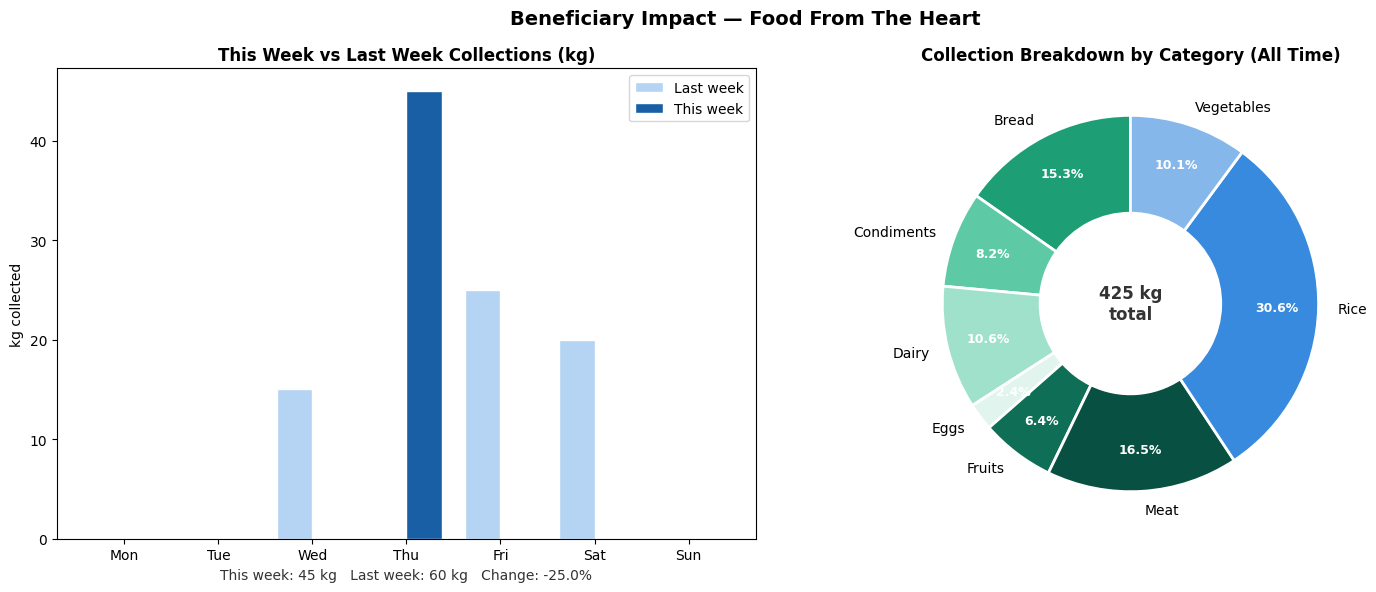

  📁 Saved: beneficiary_impact_charts.png
✅ Beneficiary impact charts complete
  This week: 45 kg  |  Last week: 60 kg  |  Change: -25.0%
  Category breakdown:
    Bread            65 kg  (15.3%)
    Condiments       35 kg  (8.2%)
    Dairy            45 kg  (10.6%)
    Eggs             10 kg  (2.4%)
    Fruits           27 kg  (6.4%)
    Meat             70 kg  (16.5%)
    Rice             130 kg  (30.6%)
    Vegetables       43 kg  (10.1%)


In [47]:
import matplotlib.patches as mpatches

print("\n📊 Generating beneficiary impact charts...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Beneficiary Impact — {BENEFICIARY["name"]}', fontsize=14, fontweight='bold')

completed = pickup_history[pickup_history['status'] == 'complete'].copy()

# ── Chart 1: This week vs last week daily collections ─────────────────────
today_dt    = pd.Timestamp.today().normalize()
week_start  = today_dt - pd.Timedelta(days=today_dt.dayofweek)        # this Monday
lweek_start = week_start - pd.Timedelta(weeks=1)
lweek_end   = week_start

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

this_week_data = completed[completed['pickup_date'] >= week_start].copy()
last_week_data = completed[
    (completed['pickup_date'] >= lweek_start) & (completed['pickup_date'] < lweek_end)
].copy()

def daily_kg(subset):
    s = subset.groupby(subset['pickup_date'].dt.dayofweek)['quantity_kg'].sum()
    return s.reindex(range(7), fill_value=0)

this_kg = daily_kg(this_week_data)
last_kg = daily_kg(last_week_data)

x = np.arange(7)
w = 0.38
axes[0].bar(x - w/2, last_kg.values, w, label='Last week', color='#B5D4F4', edgecolor='white')
axes[0].bar(x + w/2, this_kg.values, w, label='This week', color='#185FA5', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(day_labels)
axes[0].set_title('This Week vs Last Week Collections (kg)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('kg collected')
axes[0].legend()

total_this  = this_kg.sum()
total_last  = last_kg.sum()
pct = round((total_this - total_last) / total_last * 100, 1) if total_last > 0 else 0
axes[0].set_xlabel(
    f'This week: {total_this:.0f} kg   Last week: {total_last:.0f} kg   '
    f'Change: {"+" if pct >= 0 else ""}{pct}%',
    fontsize=10, color='#333333'
)

# ── Chart 2: Category donut chart ─────────────────────────────────────────
cat_kg = completed.groupby('item_name')['quantity_kg'].sum()

if len(cat_kg) == 0:
    # Fallback for empty history
    cat_kg = pd.Series({'Rice': 40, 'Bread': 60, 'Vegetables': 30,
                        'Condiments': 20, 'Dairy': 15})

colors_donut = ['#1D9E75','#5DCAA5','#9FE1CB','#E1F5EE',
                '#0F6E56','#085041','#378ADD','#85B7EB'][:len(cat_kg)]

wedges, texts, autotexts = axes[1].pie(
    cat_kg.values,
    labels=cat_kg.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_donut,
    pctdistance=0.78,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
    at.set_fontweight('bold')

centre_text = f'{cat_kg.sum():.0f} kg\ntotal'
axes[1].text(0, 0, centre_text, ha='center', va='center',
             fontsize=12, fontweight='bold', color='#333333')
axes[1].set_title('Collection Breakdown by Category (All Time)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('beneficiary_impact_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("  📁 Saved: beneficiary_impact_charts.png")
print("✅ Beneficiary impact charts complete")
print(f"  This week: {total_this:.0f} kg  |  Last week: {total_last:.0f} kg  |  Change: {'+' if pct >= 0 else ''}{pct}%")
print("  Category breakdown:")
for cat, kg in cat_kg.items():
    print(f"    {cat:15s}  {kg:.0f} kg  ({kg/cat_kg.sum()*100:.1f}%)")

---
## Stage 8: Write Beneficiary Dashboard JSON

The primary output is **`beneficiary_dashboard.json`** — a single file scoped to one specific beneficiary (`BENEFICIARY['id']`). This contains all metrics, AI matches, category breakdowns, weekly comparisons, and recently received items needed by the frontend.

Individual component files (`dashboard_metrics.json`, `ai_matches.json`, etc.) are also saved for frontend flexibility — if a page only needs one section, it can fetch just that file.

**Important:** This dashboard displays data for a **single beneficiary**, not all beneficiaries. In production, you would run this notebook once per beneficiary (or parameterise it) to generate a separate JSON for each NPO.

| File | Contents |
|---|---|
| `beneficiary_dashboard.json` | Combined payload for one beneficiary (primary output) |
| `dashboard_metrics.json` | 4 metric cards at the top |
| `ai_matches.json` | AI-recommended match cards |
| `top_categories.json` | Category bar chart data |
| `nearby_stores.json` | All stores within range |
| `recently_received.json` | Pickup history rows |

In [48]:
print("\n[7/7] Writing beneficiary dashboard JSON files...")

def save_json(data, filename):
    with open(filename, 'w') as f:
        json.dump(data, f, indent=2, default=str)
    print(f"  \u2713 Saved: {filename}")

# Compute weekly comparison values (from Stage 7b charts)
# These variables (total_this, total_last, pct) are computed in the chart cell
weekly_comparison = {
    'this_week_kg': int(total_this) if 'total_this' in dir() else 0,
    'last_week_kg': int(total_last) if 'total_last' in dir() else 0,
    'pct_change': float(pct) if 'pct' in dir() else 0
}

cat_totals_for_json = completed.groupby('item_name')['quantity_kg'].sum().sort_values(ascending=False)
category_breakdown = [
    {'category': cat, 'quantity_kg': int(qty),
     'percentage': round(qty / cat_totals_for_json.sum() * 100, 1)}
    for cat, qty in cat_totals_for_json.items()
]

# ── Single combined JSON for this beneficiary ─────────────────────────────
beneficiary_payload = {
    'generated_at':      datetime.now().isoformat(),
    'beneficiary': {
        'id':           BENEFICIARY['id'],
        'name':         BENEFICIARY['name'],
        'joined_date':  BENEFICIARY['joined_date'],
        'preferences':  BENEFICIARY['preferences']
    },
    'metrics':           metrics,
    'ai_matches':        matches,
    'top_categories':    top_categories,
    'nearby_stores':     nearby,
    'recently_received': recently_received,
    'weekly_comparison': weekly_comparison,
    'category_breakdown': category_breakdown,
}

save_json(beneficiary_payload, 'beneficiary_dashboard.json')

# Also save individual component files for frontend flexibility
save_json(metrics,           'dashboard_metrics.json')
save_json(matches,           'ai_matches.json')
save_json(top_categories,    'top_categories.json')
save_json(nearby,            'nearby_stores.json')
save_json(recently_received, 'recently_received.json')

print("\n" + "=" * 60)
print("  BENEFICIARY DASHBOARD ENGINE COMPLETE")
print("=" * 60)
print(f"  beneficiary_dashboard.json is ready for {BENEFICIARY['name']}'s frontend.")
print(f"  Dashboard shows data for beneficiary: {BENEFICIARY['id']}")
print("  Re-run this notebook daily at 6 AM to refresh the data.")
print("=" * 60)


[7/7] Writing beneficiary dashboard JSON files...
  ✓ Saved: beneficiary_dashboard.json
  ✓ Saved: dashboard_metrics.json
  ✓ Saved: ai_matches.json
  ✓ Saved: top_categories.json
  ✓ Saved: nearby_stores.json
  ✓ Saved: recently_received.json

  BENEFICIARY DASHBOARD ENGINE COMPLETE
  beneficiary_dashboard.json is ready for Food From The Heart's frontend.
  Dashboard shows data for beneficiary: BEN_001
  Re-run this notebook daily at 6 AM to refresh the data.
